# Assignment 1 - Machine Learning
## Exploratory Data Analysis (EDA) - AAPL Stock Price Dataset


In [3]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)


In [4]:
# Load Dataset
df = pd.read_csv('AAPL_Stock_Price_Dataset.csv')
df.head()


,Date,Open,High,Low,Close,Volume,Daily_Return,Price_Range,Price_Change
0,1980-12-15,0.093684,0.093684,0.093256,0.093256,175884800,NaN,0.000428,-0.000428
1,1980-12-16,0.086839,0.086839,0.086412,0.086412,105728000,-7.339797,0.000428,-0.000428
2,1980-12-17,0.088550,0.088978,0.088550,0.088550,86441600,2.475132,0.000428,0.000000
3,1980-12-18,0.091118,0.091545,0.091118,0.091118,73449600,2.899260,0.000428,0.000000
4,1980-12-19,0.096678,0.097106,0.096678,0.096678,48630400,6.102835,0.000428,0.000000


### Basic Dataset Overview


In [5]:
print('Rows:', df.shape[0])
print('Columns:', df.shape[1])
df.columns


Rows: 11354
Columns: 9


Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Daily_Return',
       'Price_Range', 'Price_Change'],
      dtype='str')

### Check Missing Values


In [6]:
df.isna().sum()


Date            0
Open            0
High            0
Low             0
Close           0
Volume          0
Daily_Return    1
Price_Range     0
Price_Change    0
dtype: int64

### Check Duplicate Rows


In [7]:
print('Duplicate rows:', df.duplicated().sum())


Duplicate rows: 0


### Data Types


In [8]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df.dtypes


Date            datetime64[us]
Open                   float64
High                   float64
Low                    float64
Close                  float64
Volume                   int64
Daily_Return           float64
Price_Range            float64
Price_Change           float64
dtype: object

### Descriptive Summary Statistics


In [9]:
df.describe().T


,count,mean,min,25%,50%,75%,max,std
Date,11354,2003-06-13 07:15:16.329047,1980-12-15 00:00:00,1992-03-06 18:00:00,2003-06-10 12:00:00,2014-09-17 18:00:00,2025-12-31 00:00:00,NaN
Open,11354.0,27.944977,0.038072,0.24593,0.481131,21.481897,286.200012,57.766472
High,11354.0,28.247652,0.038072,0.25218,0.49129,21.733548,288.619995,58.385872
Low,11354.0,27.661508,0.037645,0.240499,0.470513,21.23824,283.299988,57.201837
Close,11354.0,27.967625,0.037645,0.24577,0.48259,21.527946,286.190002,57.823221
Volume,11354.0,309717055.152369,0.0,106254850.0,198822400.0,390145000.0,7421640800.0,333417016.754992
Daily_Return,11353.0,0.109127,-51.869203,-1.242189,0.0,1.42075,33.228052,2.764016
Price_Range,11354.0,0.586144,0.0,0.007498,0.023431,0.331782,28.622127,1.400589
Price_Change,11354.0,0.022648,-14.231336,-0.009336,0.0,0.012551,26.808337,0.920067


## Univariate Analysis


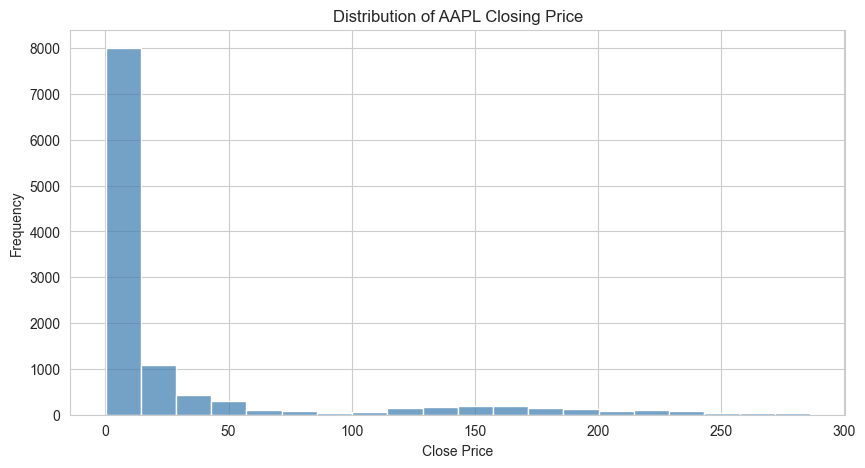

In [10]:
# Distribution of Closing Price
sns.histplot(df['Close'], bins=20, color='steelblue')
plt.title('Distribution of AAPL Closing Price')
plt.xlabel('Close Price')
plt.ylabel('Frequency')
plt.show()


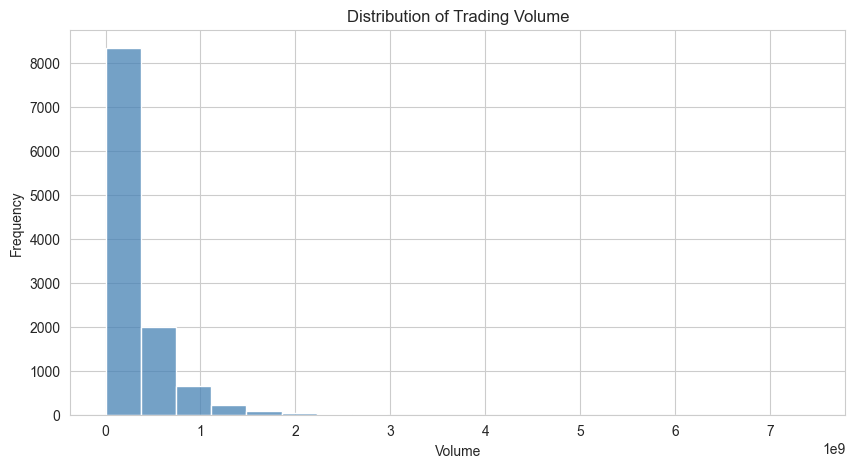

In [11]:
# Distribution of Trading Volume
sns.histplot(df['Volume'], bins=20, color='steelblue')
plt.title('Distribution of Trading Volume')
plt.xlabel('Volume')
plt.ylabel('Frequency')
plt.show()


## Bivariate Analysis


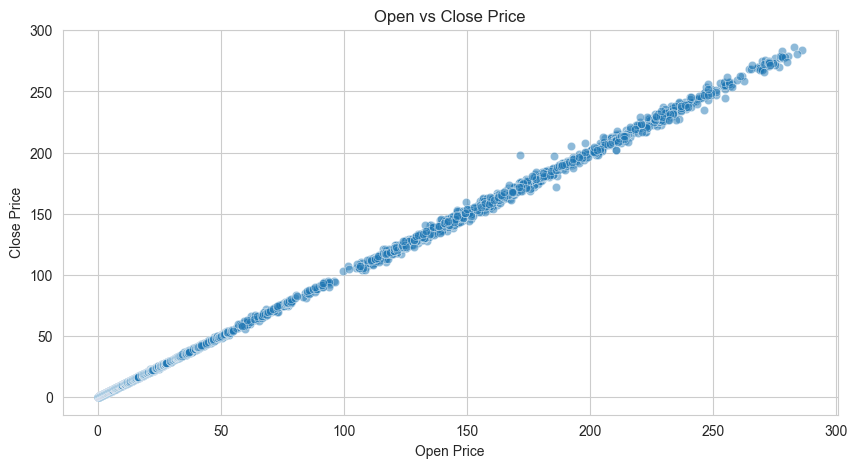

In [12]:
# Open vs Close relationship
sns.scatterplot(data=df, x='Open', y='Close', alpha=0.5)
plt.title('Open vs Close Price')
plt.xlabel('Open Price')
plt.ylabel('Close Price')
plt.show()


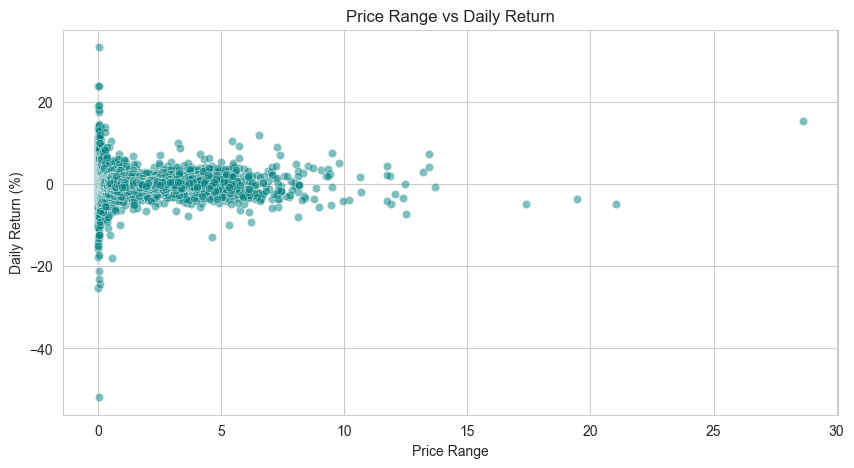

In [13]:
# High-Low spread vs Daily Return
sns.scatterplot(data=df, x='Price_Range', y='Daily_Return', alpha=0.5, color='teal')
plt.title('Price Range vs Daily Return')
plt.xlabel('Price Range')
plt.ylabel('Daily Return (%)')
plt.show()


### Correlation Matrix


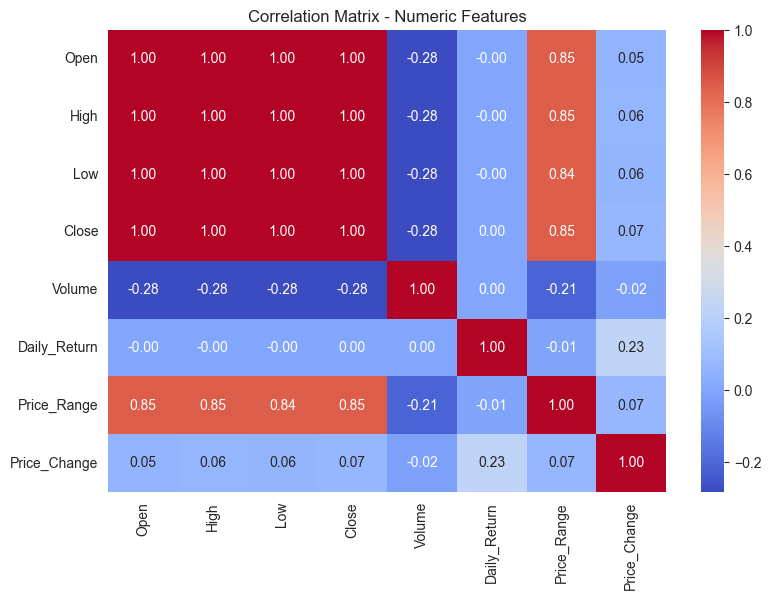

In [14]:
num_df = df.select_dtypes(include=[np.number])
corr = num_df.corr()

plt.figure(figsize=(9, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix - Numeric Features')
plt.show()


## Time-Based Analysis


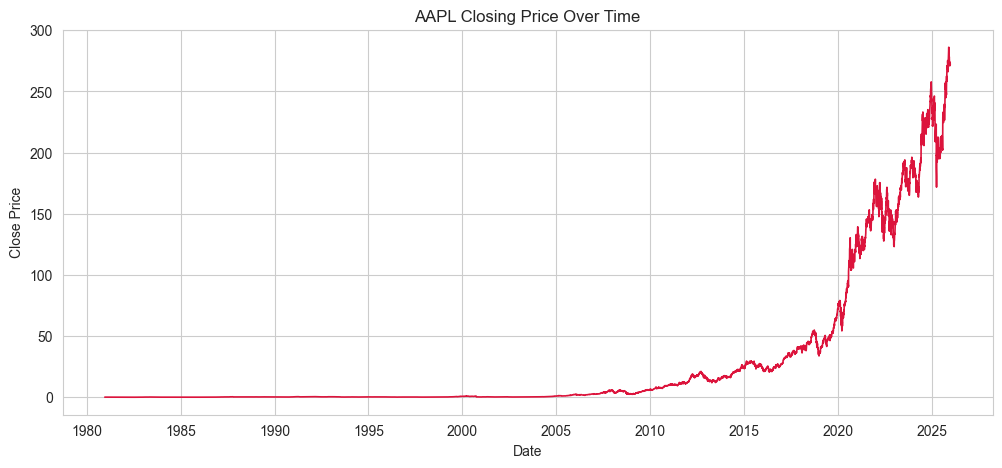

In [15]:
# Closing price trend over time
df = df.sort_values('Date')

plt.figure(figsize=(12, 5))
plt.plot(df['Date'], df['Close'], color='crimson', linewidth=1.2)
plt.title('AAPL Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.show()


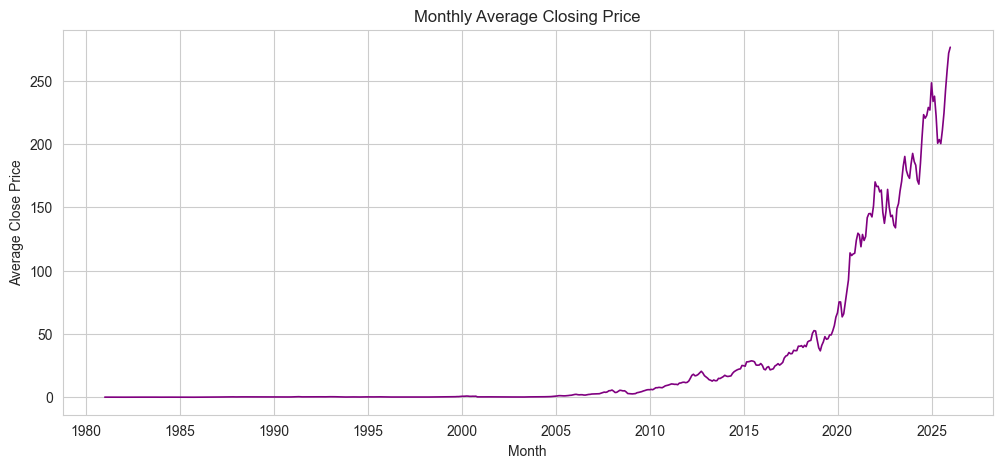

In [16]:
# Monthly average closing price
monthly_close = df.set_index('Date')['Close'].resample('ME').mean()

plt.figure(figsize=(12, 5))
plt.plot(monthly_close.index, monthly_close.values, color='purple', linewidth=1.2)
plt.title('Monthly Average Closing Price')
plt.xlabel('Month')
plt.ylabel('Average Close Price')
plt.show()


## Assignment 1
- Apple Stock Price Dataset EDA

